#### Problem:
You need to examine price_per_sqft column of given dataset and do following,
1) Remove outliers using percentile technique first. Use [0.001, 0.999] for lower and upper bound percentiles
2) After removing outliers in step 1, you get a new dataframe.
3) On step(2) dataframe, use 4 standard deviation to remove outliers
4) Plot histogram for new dataframe that is generated after step (3). Also plot bell curve on same histogram
5) On step(2) dataframe, use zscore of 4 to remove outliers. This is quite similar to step (3) and you will get exact same result

In [3]:
import pandas as pd
import seaborn as sn
from matplotlib import pyplot as plt

In [5]:
df = pd.read_csv('../ML_Maths/bhp.csv')
df.shape

(13200, 7)

In [7]:
df.head(2)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615


In [6]:
df['price_per_sqft'].describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [8]:
df_min, df_max = df['price_per_sqft'].quantile([0.001, 0.999])
df_min, df_max

(1366.184, 50959.3619999996)

In [9]:
outliers = df[(df['price_per_sqft'] < df_min) | (df['price_per_sqft'] > df_max)]
outliers.shape

(28, 7)

In [10]:
df2 = df[(df['price_per_sqft'] > df_min) & (df['price_per_sqft'] < df_max)]
df2.shape

(13172, 7)

In [11]:
df2['price_per_sqft'].describe()

count    13172.000000
mean      6663.653735
std       4141.020700
min       1379.000000
25%       4271.000000
50%       5438.000000
75%       7311.000000
max      50349.000000
Name: price_per_sqft, dtype: float64

In [12]:
min_limit = df2['price_per_sqft'].mean() - 4 *df2['price_per_sqft'].std()
min_limit

np.float64(-9900.429065502578)

In [13]:
max_limit = df2['price_per_sqft'].mean() + 4 *df2['price_per_sqft'].std()
max_limit

np.float64(23227.73653589432)

In [14]:
df3 = df2[(df2['price_per_sqft']>min_limit)&(df2['price_per_sqft']<max_limit)]
df3.sample(4)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
7880,Gunjur,2 BHK,1175.0,2.0,43.480,2,3700
3808,Bannerghatta Road,3 BHK,1600.0,3.0,95.000,3,5937
8816,Bannerghatta Road,3 BHK,1365.0,3.0,76.180,3,5580
4245,Yeshwanthpur,1 BHK,605.0,1.0,41.745,1,6899


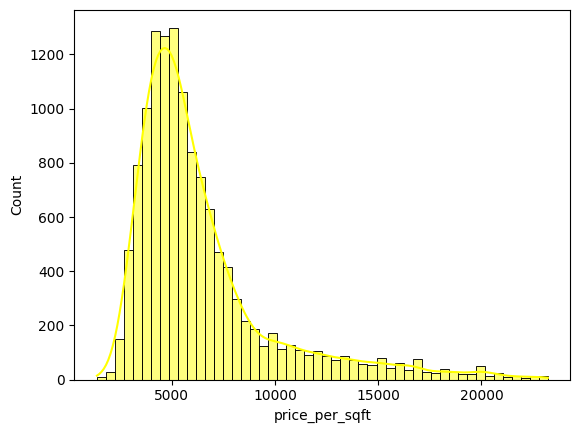

In [15]:
sn.histplot(df3['price_per_sqft'], bins=50, kde = True, color= 'yellow')
plt.show()

In [16]:
df2['z_score'] = df2['price_per_sqft'].apply(lambda x: (x - df2['price_per_sqft'].mean())/df2['price_per_sqft'].std())
df2.shape

(13172, 8)

In [17]:
outliers = df2[(df2['z_score'] < -4) | (df2['z_score'] > 4)]
outliers.shape

(125, 8)

In [18]:
df4 = df2[(df2['z_score'] > -4) & (df2['z_score'] < 4)]
df4.shape

(13047, 8)